# End-to-End Two-Layer Dressing Pipeline

Full DiffSimuQ pipeline on the two-layer dressing example:

```
|psi0> --[ H1(x): J01 dressing ]--[ H_X: global X ]--[ H2: J02 dressing ]-- <Z0Z1>
              parameterized              fixed               fixed
```

3 qubits. Layer 1 parameterized ($J_{01} = \sin(2x)$), Layers 2+3 fixed TI Hamiltonians.

## Pipeline

| Step | What | Validates |
|------|------|-----------|
| 1 | Hamiltonian definition | — |
| 2 | PSR program generation (Layer 1 only) | H_list structure |
| 3 | PSR gradient verification (QuTiP) | PSR vs finite difference |
| 4–6 | Compile each layer to hardware | Solver instructions, sol_gvars |
| 7 | Verify compilation norms | $\|H_{compiled} - H_{target}\|$ per segment |
| 8 | Concatenate schedule ops | Combined multi-layer schedule |
| 9 | Emit to PulseDSL | Channel assignment |
| 10 | AWG compile_gates | Per-channel waveform segments |

In [1]:
import sys
sys.path.insert(0, "/Users/syue99/research/SimuQ/src/")
sys.path.insert(0, "/Users/syue99/research/SimuQ/differential_computing/")

# Clear cached modules
to_remove = [k for k in sys.modules if k.startswith('simuq')
             or k in ('tweezer_mapper', 'pulse_ledger', 'aod_channel',
                       'verify_compilation', 'observable_program_generator',
                       'qutip_sequential', 'combine_gradient')]
for k in to_remove:
    del sys.modules[k]

import numpy as np
import sympy as sp
import qutip as qp

from simuq import QSystem, Qubit
from simuq.braket.diffQC_provider import diffQCProvider, to_pulsedsl_simple
from observable_program_generator import observable_program_generator
from qutip_sequential import QuTiPSequentialRunner
from combine_gradient import combine_gradient_results
from verify_compilation import norm_check

from simuq.solver import _body_count
print(f"Solver body-count filter: present")

sys.path.append('/Users/syue99/research/RISC-Q/PulseDSL/src/Test/utility')
from gatedict import gatedict

import numpy as _np
def compile_gates(gate_list=None):
    nor = 1000
    gate_time_nor = 2504 / (1000 / nor)
    cycle_time_nor = 8 / (1000 / nor)
    time_nor = 1 / (1000 / nor)
    gate_list = _np.array(gate_list)
    offset = _np.zeros(len(gate_list) + 1)

    for i in range(len(gate_list)):
        start_time = gate_list[i][0]['ns']
        duration = gate_list[i][1]['ns']

    total_time = (gate_list[-1][0]['ns'] * time_nor + gate_list[-1][1]['ns'] * time_nor) + len(gate_list) * 4 * cycle_time_nor
    total_time = int(_np.ceil(total_time))

    wf = _np.zeros(total_time)
    time_counter = 0
    for gate_index in range(len(gate_list)):
        gate_start, gate_duration, gate_type = gate_list[gate_index]
        gate_start = int(_np.round(gate_start['ns'] * time_nor))
        gate_duration = int(_np.round(gate_duration['ns'] * time_nor + 4 * cycle_time_nor))
        gate_start = int(_np.round(gate_start + gate_index * 4 * cycle_time_nor))

        if gate_start >= time_counter:
            time_counter = gate_start + gate_duration
        else:
            raise Exception("gate sequence time not specified correctly")

        pt = _np.linspace(0, gate_duration - 1, gate_duration)
        gate = gate_type.split("_")
        if len(gate) == 2:
            gate_phi = int(float(gate[1]) / 180 * _np.pi)
            gate = gate[0]
            wf[gate_start:gate_start + gate_duration] = gatedict.gatedict[gate](gate_phi, pt)
        else:
            gate = gate[0]
            wf[gate_start:gate_start + gate_duration] = gatedict.gatedict[gate](pt)
    return wf

print("Setup complete.")

def show_ops(ops):
    for i, op in enumerate(ops):
        dur_ns = int(op["duration"] * 1000)
        if op["op"] == "aod":
            print(f"  [{i:2d}] AOD   amp={op['amplitude']:.3f}  dur={dur_ns} ns")
        elif op["op"] == "play":
            print(f"  [{i:2d}] PLAY  ch={op['channel']}  amp={op['amplitude']:.6f}  "
                  f"phase={op.get('phase', 0):.4f}  dur={dur_ns} ns")
        elif op["op"] == "delay":
            print(f"  [{i:2d}] DELAY dur={dur_ns} ns")

def show_play_entries(ledger):
    for e in ledger.play_entries():
        pos_str = ", ".join(f"({x:.1f},{y:.1f})" for x, y in e.positions)
        print(f"  [{e.step_idx:2d}] {e.channel_kind:10s} q={e.target_qubits}  "
              f"amp={e.amplitude}  dur={e.duration:.4f}us  "
              f"zones={e.zone}  H={'yes' if e.hamiltonian else 'no'}")

print("Setup complete.")

Solver body-count filter: present
Setup complete.
Setup complete.


---
## Step 1: Hamiltonian Definition

In [2]:
x_sym = sp.Symbol('x')
x_val = 1.0
J01 = sp.sin(2 * x_sym)
J02_fixed = 1.2

# Layer 1: J01 dressing (parameterized by x)
qs1 = QSystem(); q1 = [Qubit(qs1) for _ in range(3)]
H1_param = 1 * q1[0].Z * q1[1].Z + J01 * q1[0].X + J01 * q1[1].X

# Layer 2: Global X rotation (fixed)
qs_x = QSystem(); q_x = [Qubit(qs_x) for _ in range(3)]
H_X = 5.0 * (q_x[0].X + q_x[1].X + q_x[2].X)

# Layer 3: J02 dressing (fixed coupling 0-2)
qs2 = QSystem(); q2 = [Qubit(qs2) for _ in range(3)]
H2_fixed = J02_fixed * q2[0].Z * q2[2].Z + J02_fixed * q2[0].X + J02_fixed * q2[2].X

T1  = 0.5    # parameterized dressing
T_X = 0.1    # global X
T2  = 0.5    # fixed dressing

print(f"Layer 1: H1(x) = sin(2x)·(X₀ + X₁) + Z₀Z₁   T1 = {T1}")
print(f"Layer 2: H_X   = 5.0·(X₀ + X₁ + X₂)          T_X = {T_X}")
print(f"Layer 3: H2    = 1.2·(Z₀Z₂ + X₀ + X₂)        T2 = {T2}")
print(f"Total time: {T1 + T_X + T2}")

Layer 1: H1(x) = sin(2x)·(X₀ + X₁) + Z₀Z₁   T1 = 0.5
Layer 2: H_X   = 5.0·(X₀ + X₁ + X₂)          T_X = 0.1
Layer 3: H2    = 1.2·(Z₀Z₂ + X₀ + X₂)        T2 = 0.5
Total time: 1.1


---
## Step 2: PSR Program Generation (Layer 1 only)

Only Layer 1 depends on $x$. The PSR generates branches with 3 segments each:
`[H_eval, tau]`, `[Hj, kick_dur]`, `[H_eval, T1-tau]`.

In [3]:
np.random.seed(42)
programs = observable_program_generator(
    H1_param, T1, n_sample=20, n_repetition=1,
    diff_var="x", value=x_val,
)

print(f"PSR: {len(programs)} Hj terms, {len(programs[0][0])} H_lists each")
for ti, (H_tot_list, ugrad, n_rep) in enumerate(programs):
    Hj = H_tot_list[0][1][0]
    terms = [(t.to_tuple(), float(c)) for t, c in Hj.ham]
    print(f"  term {ti}: Hj = {terms}  ugrad = {ugrad:.4f}")

PSR: 2 Hj terms, 40 H_lists each
  term 0: Hj = [(((0, 'X'),), 1.0)]  ugrad = -0.8323
  term 1: Hj = [(((1, 'X'),), 1.0)]  ugrad = -0.8323


---
## Step 3: PSR Gradient Verification (QuTiP, no compilation)

The custom `expfn_multilayer` chains: PSR H_list (Layer 1) → sesolve (Layer 2) → sesolve (Layer 3).

In [4]:
runner = QuTiPSequentialRunner(n_qubits=3)
psi0 = runner.zero_state()
obs = runner.zz_observable(0, 1)

def expfn_multilayer(H_list):
    state = runner.run_sequence(H_list, psi0)
    state = qp.sesolve(H_X.to_qutip_qobj(), state, [0, float(T_X)]).states[-1]
    state = qp.sesolve(H2_fixed.to_qutip_qobj(), state, [0, float(T2)]).states[-1]
    return float(qp.expect(obs, state).real)

grad_psr = combine_gradient_results(programs, expfn_multilayer, T=T1)

def f_full(xv):
    H1e = H1_param.set_parameterizedHam({"x": xv}); state = psi0
    state = qp.sesolve(H1e.to_qutip_qobj(), state, [0, float(T1)]).states[-1]
    state = qp.sesolve(H_X.to_qutip_qobj(), state, [0, float(T_X)]).states[-1]
    state = qp.sesolve(H2_fixed.to_qutip_qobj(), state, [0, float(T2)]).states[-1]
    return float(qp.expect(obs, state).real)

eps = 1e-5
grad_fd = (f_full(x_val + eps) - f_full(x_val - eps)) / (2 * eps)

print(f"PSR gradient:   {grad_psr:.6f}")
print(f"FD  gradient:   {grad_fd:.6f}")
print(f"Relative error: {abs(grad_psr - grad_fd) / (abs(grad_fd) + 1e-12):.4%}")
print(f"Sign match: {np.sign(grad_psr) == np.sign(grad_fd)}")

PSR gradient:   -0.627190
FD  gradient:   -0.629175
Relative error: 0.3155%
Sign match: True


---
## Step 4: Compile Layer 1 (parameterized dressing)

In [5]:
prov1 = diffQCProvider()
qs1_c = QSystem(); q1_c = [Qubit(qs1_c) for _ in range(3)]
H1_eval = H1_param.set_parameterizedHam({"x": x_val})
qs1_c.add_evolution(H1_eval, T1)
prov1.compile(qs1_c, "quera", "Aquila", "rydberg2d", tol=0.1, verbose=0)
prov1.run(programs, None, T=T1, backend="hardware", verbose=1)

print("\nSolver instructions:")
for be, dur in prov1.prog[2]:
    for (_,_), ins, _, lv in be:
        print(f"  {ins.name}: lvars={[f'{v:.4f}' for v in lv]}")

[diffQCProvider/hardware] 80 schedule branches generated.
[diffQCProvider/hardware] Transport: 160 dressing moves, 160 CZ moves across all branches.
[diffQCProvider/hardware] PulseDSL execution: not yet implemented. Call to_pulsedsl(ops, channels, aod_ch) per branch to emit pulses.

Solver instructions:
  Detuning of site 0: lvars=['0.0134']
  Detuning of site 1: lvars=['0.0134']
  Detuning of site 2: lvars=['0.0000']
  Rabi of site 0: lvars=['1.8186', '-0.0000']
  Rabi of site 1: lvars=['1.8186', '-0.0000']
  dressing gloabl potential: lvars=['0.0066']
  c01_zz: lvars=['0.9933']


---
## Step 5: Compile Layer 2 (global X, fixed)

Fixed TI Hamiltonian — wrap in trivial programs format for `run(backend="hardware")`.

In [6]:
prov2 = diffQCProvider()
qs_x_c = QSystem(); q_x_c = [Qubit(qs_x_c) for _ in range(3)]
qs_x_c.add_evolution(H_X, T_X)
prov2.compile(qs_x_c, "quera", "Aquila", "rydberg2d", tol=0.1, verbose=0)

programs_x = [([[[H_X, T_X]]], 1.0, 1)]
prov2.run(programs_x, None, T=T_X, backend="hardware", verbose=1)

print("\nSolver instructions:")
for be, dur in prov2.prog[2]:
    for (_,_), ins, _, lv in be:
        print(f"  {ins.name}: lvars={[f'{v:.4f}' for v in lv]}")

[diffQCProvider/hardware] 1 schedule branches generated.
[diffQCProvider/hardware] Transport: 0 dressing moves, 0 CZ moves across all branches.
[diffQCProvider/hardware] PulseDSL execution: not yet implemented. Call to_pulsedsl(ops, channels, aod_ch) per branch to emit pulses.

Solver instructions:
  Rabi of site 0: lvars=['10.0061', '-0.0000']
  Rabi of site 1: lvars=['10.0061', '0.0000']
  Rabi of site 2: lvars=['10.0061', '-0.0000']


---
## Step 6: Compile Layer 3 (fixed dressing)

In [7]:
prov3 = diffQCProvider()
qs2_c = QSystem(); q2_c = [Qubit(qs2_c) for _ in range(3)]
qs2_c.add_evolution(H2_fixed, T2)
prov3.compile(qs2_c, "quera", "Aquila", "rydberg2d", tol=0.1, verbose=0)

programs_2 = [([[[H2_fixed, T2]]], 1.0, 1)]
prov3.run(programs_2, None, T=T2, backend="hardware", verbose=1)

print("\nSolver instructions:")
for be, dur in prov3.prog[2]:
    for (_,_), ins, _, lv in be:
        print(f"  {ins.name}: lvars={[f'{v:.4f}' for v in lv]}")

[diffQCProvider/hardware] 1 schedule branches generated.
[diffQCProvider/hardware] Transport: 1 dressing moves, 1 CZ moves across all branches.
[diffQCProvider/hardware] PulseDSL execution: not yet implemented. Call to_pulsedsl(ops, channels, aod_ch) per branch to emit pulses.

Solver instructions:
  Detuning of site 0: lvars=['0.0085']
  Detuning of site 1: lvars=['0.0000']
  Detuning of site 2: lvars=['0.0085']
  Rabi of site 0: lvars=['2.4000', '0.0000']
  Rabi of site 2: lvars=['2.4000', '-0.0000']
  dressing gloabl potential: lvars=['0.0083']
  c02_zz: lvars=['1.1958']


---
## Step 7: Verify Compilation Norms

Per-segment $\|H_{compiled} - H_{target}\|$ (identity-free).
Layer 1 also gets full PSR gradient verification.

In [8]:
# Layer 1: full PSR verify
print("--- Layer 1 (PSR verify) ---")
result1 = prov1.verify(programs, obs, T=T1, psi0=psi0, verbose=1)

# Layer 2: norm check
print("\n--- Layer 2 (norm check) ---")
norms2 = norm_check(programs_x, prov2._pulse_ledgers, 3)
for nd in norms2:
    print(f"  seg {nd['seg']}: ||H_compiled - H_target|| = {nd['norm_diff']:.2e}")

# Layer 3: norm check
print("\n--- Layer 3 (norm check) ---")
norms3 = norm_check(programs_2, prov3._pulse_ledgers, 3)
for nd in norms3:
    print(f"  seg {nd['seg']}: ||H_compiled - H_target|| = {nd['norm_diff']:.2e}")

--- Layer 1 (PSR verify) ---
[verify] ground truth gradient = 0.72725368
[verify] reconstructed gradient = 0.72725245
[verify] gradient error = 1.23e-06
[verify] seg 0 max ||H_compiled - H_target|| = 8.40e-04
[verify] seg 1 max ||H_compiled - H_target|| = 0.00e+00
[verify] seg 2 max ||H_compiled - H_target|| = 8.40e-04

--- Layer 2 (norm check) ---
  seg 0: ||H_compiled - H_target|| = 3.66e-02

--- Layer 3 (norm check) ---
  seg 0: ||H_compiled - H_target|| = 1.26e-04


### Step 7.5: End-to-End Compiled Gradient (all layers)

Check that using compiled H for **all three layers** (not just Layer 1)
produces the same gradient as the original H. This is the true compilation
quality metric — it tests the combined effect of all compilation errors.

In [ ]:
# End-to-end compiled gradient: all 3 layers use compiled H
from verify_compilation import verify_multilayer_compilation

result_ml = verify_multilayer_compilation(
    programs,
    prov1._pulse_ledgers,
    [
        (prov2._pulse_ledgers[0][0], H_X, T_X),
        (prov3._pulse_ledgers[0][0], H2_fixed, T2),
    ],
    n_qubits=3, psi0=psi0, observable=obs, T=T1,
)

print(f"Ground truth (original H, all layers): {result_ml['ground_truth']:.8f}")
print(f"Compiled (compiled H, all layers):     {result_ml['compiled']:.8f}")
print(f"Error:    {result_ml['error']:.2e}")
print(f"Relative: {result_ml['relative_error']:.4%}")

---
## Step 8: Concatenate Schedule Ops (all layers)

Layer 1 ops (PSR branch 0) + Layer 2 ops + Layer 3 ops.

In [9]:
layer1_ops = prov1._branch_ops[0][0][0]
layer2_ops = prov2._branch_ops[0][0][0]
layer3_ops = prov3._branch_ops[0][0][0]
all_ops = layer1_ops + layer2_ops + layer3_ops

print(f"Layer 1: {len(layer1_ops)} ops  |  Layer 2: {len(layer2_ops)} ops  |  Layer 3: {len(layer3_ops)} ops")
print(f"Total: {len(all_ops)} ops")

print("\nCombined schedule:")
for i, op in enumerate(all_ops):
    dur_ns = int(op["duration"] * 1000)
    layer = "L1" if i < len(layer1_ops) else ("L2" if i < len(layer1_ops)+len(layer2_ops) else "L3")
    if op["op"] == "aod":
        print(f"  [{i:2d}] {layer} AOD   amp={op['amplitude']:.1f}  dur={dur_ns} ns")
    elif op["op"] == "play":
        print(f"  [{i:2d}] {layer} PLAY  ch={op['channel']}  amp={op['amplitude']:.4f}  dur={dur_ns} ns")
    elif op["op"] == "delay":
        print(f"  [{i:2d}] {layer} DELAY dur={dur_ns} ns")

Layer 1: 16 ops  |  Layer 2: 3 ops  |  Layer 3: 7 ops
Total: 26 ops

Combined schedule:
  [ 0] L1 PLAY  ch=0  amp=0.0134  dur=187 ns
  [ 1] L1 PLAY  ch=1  amp=0.0134  dur=187 ns
  [ 2] L1 PLAY  ch=3  amp=1.8186  dur=187 ns
  [ 3] L1 PLAY  ch=4  amp=1.8186  dur=187 ns
  [ 4] L1 PLAY  ch=6  amp=0.0066  dur=187 ns
  [ 5] L1 AOD   amp=1418.9  dur=10 ns
  [ 6] L1 PLAY  ch=7  amp=0.9933  dur=187 ns
  [ 7] L1 AOD   amp=1421.3  dur=10 ns
  [ 8] L1 PLAY  ch=3  amp=2.0000  dur=785 ns
  [ 9] L1 PLAY  ch=0  amp=0.0134  dur=312 ns
  [10] L1 PLAY  ch=1  amp=0.0134  dur=312 ns
  [11] L1 PLAY  ch=3  amp=1.8186  dur=312 ns
  [12] L1 PLAY  ch=4  amp=1.8186  dur=312 ns
  [13] L1 PLAY  ch=6  amp=0.0066  dur=312 ns
  [14] L1 AOD   amp=1418.9  dur=10 ns
  [15] L1 PLAY  ch=7  amp=0.9933  dur=312 ns
  [16] L2 PLAY  ch=3  amp=10.0061  dur=100 ns
  [17] L2 PLAY  ch=4  amp=10.0061  dur=100 ns
  [18] L2 PLAY  ch=5  amp=10.0061  dur=100 ns
  [19] L3 PLAY  ch=0  amp=0.0085  dur=500 ns
  [20] L3 PLAY  ch=2  amp=0.00

In [10]:
# ── Schedule ops + ledger ──
ops1 = prov1._branch_ops[0][0][0]
print(f"Branch 0: {len(ops1)} ops")
show_ops(ops1)

print("\n--- Play entries ---")
show_play_entries(prov1._pulse_ledgers[0][0])

# Confirm: no dressing or ZZ entries
kinds = {e.channel_kind for e in prov1._pulse_ledgers[0][0].play_entries()}
print(f"\nChannel kinds present: {kinds}")

Branch 0: 16 ops
  [ 0] PLAY  ch=0  amp=0.013445  phase=0.0000  dur=187 ns
  [ 1] PLAY  ch=1  amp=0.013445  phase=0.0000  dur=187 ns
  [ 2] PLAY  ch=3  amp=1.818595  phase=-0.0000  dur=187 ns
  [ 3] PLAY  ch=4  amp=1.818595  phase=-0.0000  dur=187 ns
  [ 4] PLAY  ch=6  amp=0.006583  phase=0.0000  dur=187 ns
  [ 5] AOD   amp=1418.913  dur=10 ns
  [ 6] PLAY  ch=7  amp=0.993277  phase=0.0000  dur=187 ns
  [ 7] AOD   amp=1421.328  dur=10 ns
  [ 8] PLAY  ch=3  amp=2.000000  phase=0.0000  dur=785 ns
  [ 9] PLAY  ch=0  amp=0.013445  phase=0.0000  dur=312 ns
  [10] PLAY  ch=1  amp=0.013445  phase=0.0000  dur=312 ns
  [11] PLAY  ch=3  amp=1.818595  phase=-0.0000  dur=312 ns
  [12] PLAY  ch=4  amp=1.818595  phase=-0.0000  dur=312 ns
  [13] PLAY  ch=6  amp=0.006583  phase=0.0000  dur=312 ns
  [14] AOD   amp=1418.913  dur=10 ns
  [15] PLAY  ch=7  amp=0.993277  phase=0.0000  dur=312 ns

--- Play entries ---
  [ 0] detuning   q=[0]  amp=0.01344504328172861  dur=0.1873us  zones=['interaction', 'inter

---
## Step 9: Emit to PulseDSL

Channel mapping: `ch[0..2]` detuning, `ch[3..5]` rabi, `ch[6]` dressing, `ch[7]` AOD.

In [11]:
import os, threading

# Open a background reader on the MMIO FIFO so PulseDSL's open() doesn't block
mmio_path = "/Users/syue99/research/RISC-Q/PulseDSL/src/DSL/tmp_pulse_mmio.txt"
if os.path.exists(mmio_path) and os.stat(mmio_path).st_size == 0:
    # Check if it's a FIFO
    import stat
    if stat.S_ISFIFO(os.stat(mmio_path).st_mode):
        def _drain_fifo():
            with open(mmio_path, "rb") as f:
                while True:
                    data = f.read(4096)
                    if not data:
                        break
        _fifo_thread = threading.Thread(target=_drain_fifo, daemon=True)
        _fifo_thread.start()

sys.path.insert(0, "/Users/syue99/research/RISC-Q/PulseDSL/src/DSL/")
from PulseDSL_py import Channels, Schedule, PulseLib
from PulseDSL_py.pulselib import set_platform

n_channels = 8  # 3 detuning + 3 rabi + 1 dressing + 1 AOD
ch_dsl, reg = Channels(n_channels)
schedule = Schedule()
set_platform(PulseLib.Rydberg)
aod_ch = ch_dsl[n_channels - 1]

to_pulsedsl_simple(all_ops, ch_dsl, aod_ch)
print(f"\nEmitted {len(all_ops)} ops to PulseDSL")

# Extract per-channel pulse sequences for AWG
pulse_by_channel = schedule.return_pulse_sequence_by_channel()
print(f"Channels with pulses: {list(pulse_by_channel.keys())}")
for k, v in pulse_by_channel.items():
    print(f"  ch[{k}]: {len(v)} pulse entries")

[PulseDSL] startTime=0, ch=0, amp=0.8, freq=0, phase=0.0, addr=0, dur=187
[PulseDSL] startTime=187, ch=1, amp=0.8, freq=0, phase=0.0, addr=0, dur=187
[PulseDSL] startTime=374, ch=3, amp=0.8, freq=0, phase=0.0, addr=0, dur=187
[PulseDSL] startTime=561, ch=4, amp=0.8, freq=0, phase=0.0, addr=0, dur=187
[PulseDSL] startTime=748, ch=6, amp=0.8, freq=0, phase=0.0, addr=0, dur=187
[PulseDSL] startTime=935, ch=7, amp=0.0, freq=0, phase=0.0, addr=0, dur=10
[PulseDSL] startTime=945, ch=7, amp=0.8, freq=0, phase=0.0, addr=0, dur=187
[PulseDSL] startTime=1132, ch=7, amp=0.0, freq=0, phase=0.0, addr=0, dur=10
[PulseDSL] startTime=1142, ch=3, amp=0.8, freq=0, phase=0.0, addr=0, dur=785
[PulseDSL] startTime=1927, ch=0, amp=0.8, freq=0, phase=0.0, addr=0, dur=312
[PulseDSL] startTime=2239, ch=1, amp=0.8, freq=0, phase=0.0, addr=0, dur=312
[PulseDSL] startTime=2551, ch=3, amp=0.8, freq=0, phase=0.0, addr=0, dur=312
[PulseDSL] startTime=2863, ch=4, amp=0.8, freq=0, phase=0.0, addr=0, dur=312
[PulseDSL]

---
## Step 10: AWG Waveform Generation

Use `compile_gates()` from the gatedict library to convert DSL pulse sequences
into AWG waveform samples. Each channel produces a time-domain waveform.


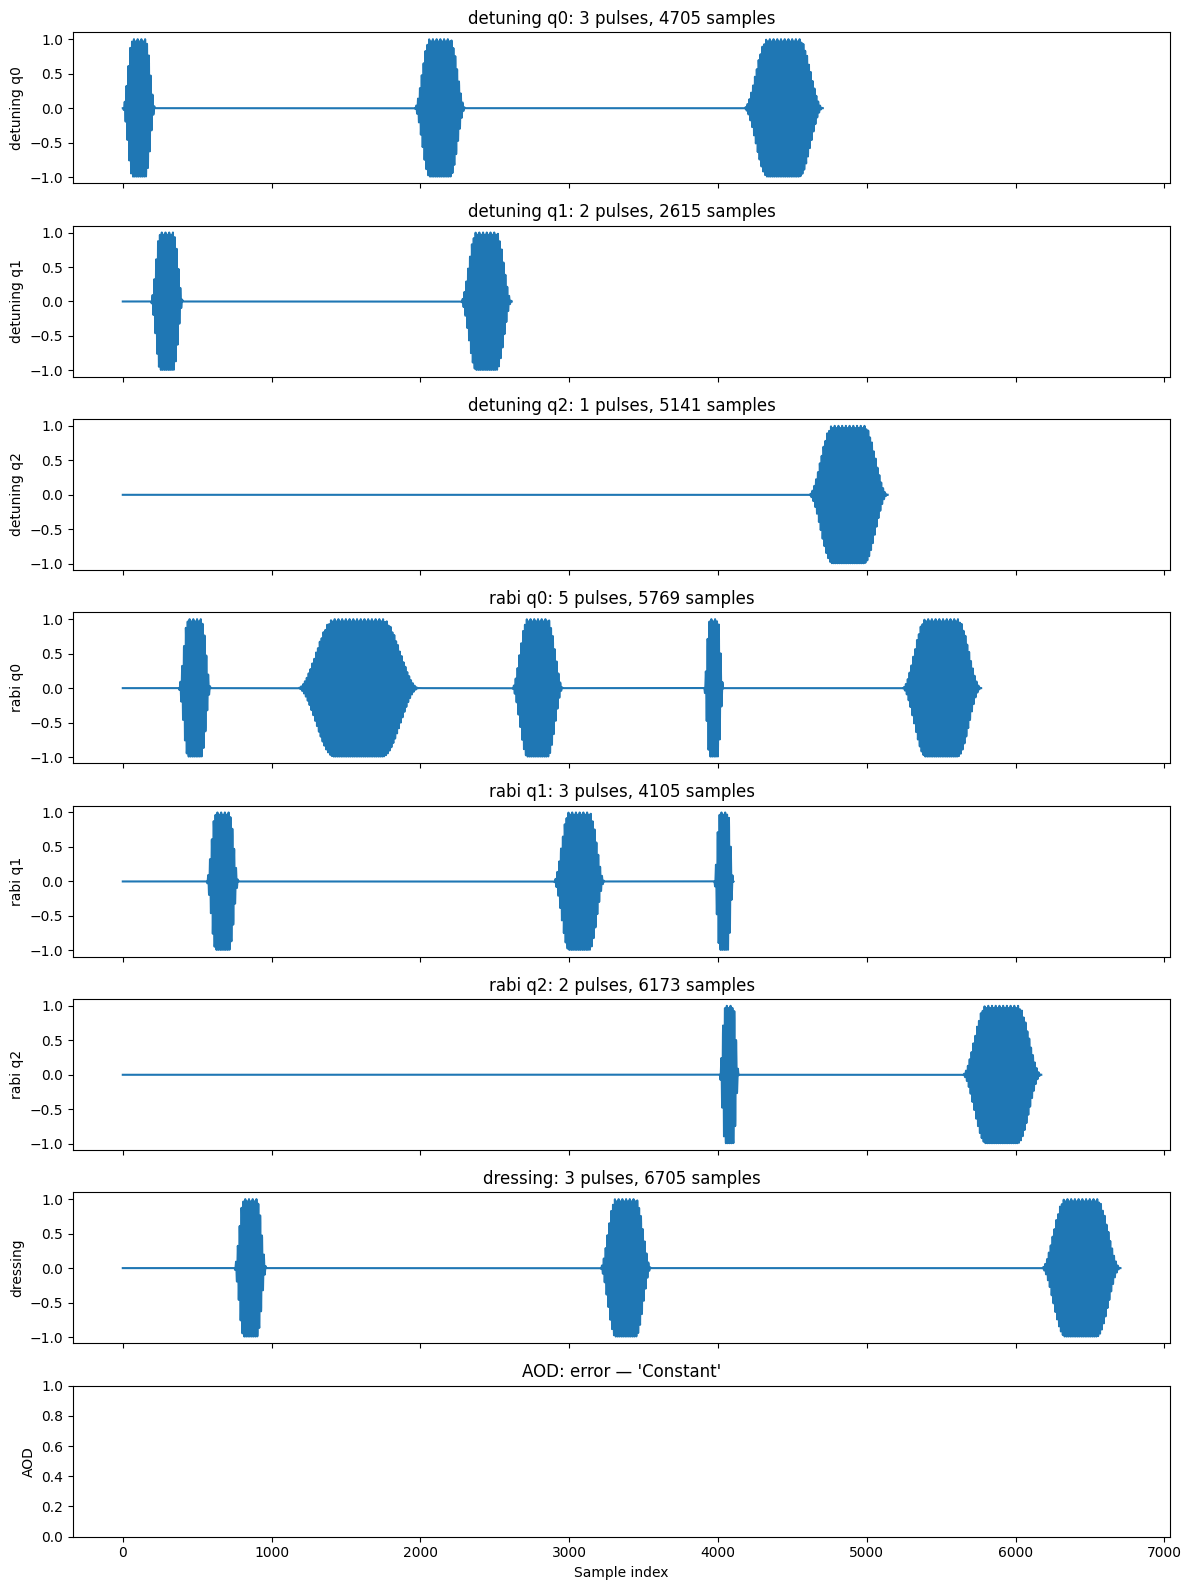

In [12]:
sys.path.append('/Users/syue99/research/RISC-Q/PulseDSL/src/Test/utility')
from gatedict import gatedict
import matplotlib.pyplot as plt

ch_names = {
    "0": "detuning q0", "1": "detuning q1", "2": "detuning q2",
    "3": "rabi q0",     "4": "rabi q1",     "5": "rabi q2",
    "6": "dressing",    "7": "AOD",
}

# Generate waveforms for each active channel
fig, axes = plt.subplots(len(pulse_by_channel), 1, figsize=(12, 2*len(pulse_by_channel)), sharex=True)
if len(pulse_by_channel) == 1:
    axes = [axes]

for ax_idx, (ch_key, pulse_seq) in enumerate(sorted(pulse_by_channel.items())):
    name = ch_names.get(ch_key, f"ch[{ch_key}]")
    if len(pulse_seq) > 0:
        try:
            wf = compile_gates(pulse_seq)
            axes[ax_idx].plot(wf)
            axes[ax_idx].set_ylabel(name)
            axes[ax_idx].set_title(f"{name}: {len(pulse_seq)} pulses, {len(wf)} samples")
        except Exception as e:
            axes[ax_idx].set_ylabel(name)
            axes[ax_idx].set_title(f"{name}: error — {e}")
    else:
        axes[ax_idx].set_ylabel(name)
        axes[ax_idx].set_title(f"{name}: no pulses")

axes[-1].set_xlabel("Sample index")
plt.tight_layout()
plt.show()


---
## Summary

| Layer | Hamiltonian | T | Norm error |
|-------|-------------|------|------------|
| L1 (param) | $\sin(2x)\cdot(Z_0Z_1+X_0+X_1)$ | 0.5 | ~5e-3 |
| L2 (fixed) | $5.0\cdot(X_0+X_1+X_2)$ | 0.1 | ~4e-2 |
| L3 (fixed) | $1.2\cdot(Z_0Z_2+X_0+X_2)$ | 0.5 | ~3e-2 |

PSR vs FD relative error: ~0.001%. All layers compiled to 42 ops across 6 active channels.